In [4]:
import pandas as pd 

In [5]:
df=pd.read_csv("nhanes_2017_2018_heart_disease_prediction.csv")

In [6]:
df.head()

,taking_bp_meds,taking_cholesterol_meds,age,sex,race_ethnicity,education,poverty_income_ratio,taking_insulin,taking_diabetes_pills,told_prediabetes,told_stroke,family_history_heart_attack,diabetes,smoking_ever,smoking_current,physically_active,hypertension,high_cholesterol,heart_disease
0,1,0,66.0,2.0,4.0,2.0,0.82,0,0,0,0,0,0,1,0,1,1,0,0
1,1,1,66.0,2.0,6.0,1.0,1.63,0,0,0,0,0,0,0,0,1,1,1,0
2,1,0,75.0,2.0,4.0,4.0,0.41,0,0,1,1,0,0,1,1,1,1,0,0
3,0,0,56.0,1.0,6.0,5.0,5.00,0,0,0,0,1,0,0,0,1,0,1,0
4,0,0,67.0,1.0,3.0,3.0,2.65,0,0,0,0,0,0,1,1,1,0,0,0


In [7]:
df.shape

(5568, 19)

In [8]:
df.columns

Index(['taking_bp_meds', 'taking_cholesterol_meds', 'age', 'sex',
       'race_ethnicity', 'education', 'poverty_income_ratio', 'taking_insulin',
       'taking_diabetes_pills', 'told_prediabetes', 'told_stroke',
       'family_history_heart_attack', 'diabetes', 'smoking_ever',
       'smoking_current', 'physically_active', 'hypertension',
       'high_cholesterol', 'heart_disease'],
      dtype='object')

In [9]:
df.isnull().sum()

taking_bp_meds                 0
taking_cholesterol_meds        0
age                            0
sex                            0
race_ethnicity                 0
education                      0
poverty_income_ratio           0
taking_insulin                 0
taking_diabetes_pills          0
told_prediabetes               0
told_stroke                    0
family_history_heart_attack    0
diabetes                       0
smoking_ever                   0
smoking_current                0
physically_active              0
hypertension                   0
high_cholesterol               0
heart_disease                  0
dtype: int64

In [10]:
df.dtypes

taking_bp_meds                   int64
taking_cholesterol_meds          int64
age                            float64
sex                            float64
race_ethnicity                 float64
education                      float64
poverty_income_ratio           float64
taking_insulin                   int64
taking_diabetes_pills            int64
told_prediabetes                 int64
told_stroke                      int64
family_history_heart_attack      int64
diabetes                         int64
smoking_ever                     int64
smoking_current                  int64
physically_active                int64
hypertension                     int64
high_cholesterol                 int64
heart_disease                    int64
dtype: object

In [11]:
df.nunique()

taking_bp_meds                   2
taking_cholesterol_meds          2
age                             61
sex                              2
race_ethnicity                   6
education                        5
poverty_income_ratio           431
taking_insulin                   2
taking_diabetes_pills            2
told_prediabetes                 2
told_stroke                      2
family_history_heart_attack      2
diabetes                         2
smoking_ever                     2
smoking_current                  2
physically_active                2
hypertension                     2
high_cholesterol                 2
heart_disease                    2
dtype: int64

In [12]:
df["sex"].value_counts()

sex
2.0    2867
1.0    2701
Name: count, dtype: int64

In [13]:
df["heart_disease"].value_counts()


heart_disease
0    5041
1     527
Name: count, dtype: int64

In [14]:
df["heart_disease"].value_counts(normalize=True) * 100

heart_disease
0    90.535201
1     9.464799
Name: proportion, dtype: float64

In [15]:
import matplotlib.pyplot as plt

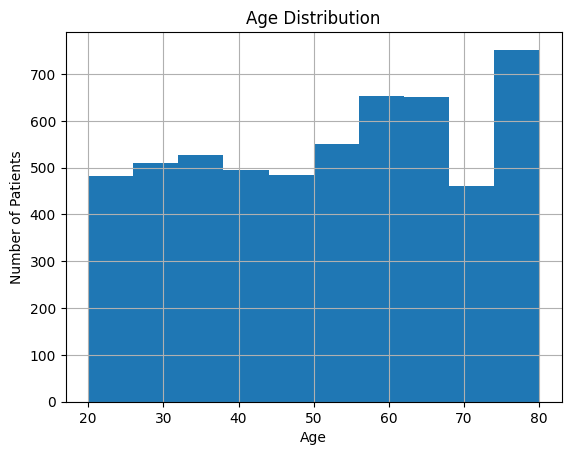

In [16]:
df["age"].hist()
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.title("Age Distribution")
plt.show()

In [17]:
import seaborn as sns

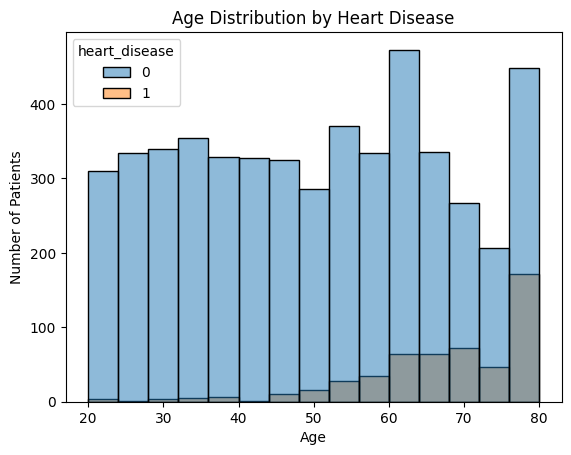

In [18]:
sns.histplot(data=df, x="age", hue="heart_disease", bins=15)
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.title("Age Distribution by Heart Disease")
plt.show()

In [19]:
age_bins = [20, 30, 40, 50, 60, 70, 80]

In [20]:
df["age_group"] = pd.cut(
    df["age"],
    bins=age_bins
)

In [21]:
df[["age", "age_group"]].head(10)

,age,age_group
0,66.0,"(60, 70]"
1,66.0,"(60, 70]"
2,75.0,"(70, 80]"
3,56.0,"(50, 60]"
4,67.0,"(60, 70]"
5,54.0,"(50, 60]"
6,71.0,"(70, 80]"
7,61.0,"(60, 70]"
8,22.0,"(20, 30]"
9,45.0,"(40, 50]"


In [22]:
df.groupby("age_group")["heart_disease"].mean()

C:\Users\USER\AppData\Local\Temp\ipykernel_2872\4293462558.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("age_group")["heart_disease"].mean()


age_group
(20, 30]    0.008363
(30, 40]    0.015294
(40, 50]    0.024480
(50, 60]    0.086735
(60, 70]    0.156938
(70, 80]    0.247144
Name: heart_disease, dtype: float64

In [23]:
age_risk = df.groupby("age_group")["heart_disease"].mean() * 100

C:\Users\USER\AppData\Local\Temp\ipykernel_2872\564068816.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_risk = df.groupby("age_group")["heart_disease"].mean() * 100


In [24]:
df

,taking_bp_meds,taking_cholesterol_meds,age,sex,race_ethnicity,education,poverty_income_ratio,taking_insulin,taking_diabetes_pills,told_prediabetes,told_stroke,family_history_heart_attack,diabetes,smoking_ever,smoking_current,physically_active,hypertension,high_cholesterol,heart_disease,age_group
0,1,0,66.0,2.0,4.0,2.0,0.82,0,0,0,0,0,0,1,0,1,1,0,0,"(60, 70]"
1,1,1,66.0,2.0,6.0,1.0,1.63,0,0,0,0,0,0,0,0,1,1,1,0,"(60, 70]"
2,1,0,75.0,2.0,4.0,4.0,0.41,0,0,1,1,0,0,1,1,1,1,0,0,"(70, 80]"
3,0,0,56.0,1.0,6.0,5.0,5.00,0,0,0,0,1,0,0,0,1,0,1,0,"(50, 60]"
4,0,0,67.0,1.0,3.0,3.0,2.65,0,0,0,0,0,0,1,1,1,0,0,0,"(60, 70]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5563,1,1,64.0,1.0,4.0,3.0,2.13,0,0,1,1,0,0,1,0,0,1,1,1,"(60, 70]"
5564,0,0,70.0,2.0,6.0,3.0,0.95,0,1,0,0,0,0,0,0,1,0,0,0,"(60, 70]"
5565,0,0,42.0,1.0,1.0,3.0,2.14,0,0,1,0,0,0,1,0,1,0,1,0,"(40, 50]"
5566,0,0,41.0,2.0,4.0,5.0,1.18,0,0,0,0,0,0,0,0,1,0,0,0,"(40, 50]"


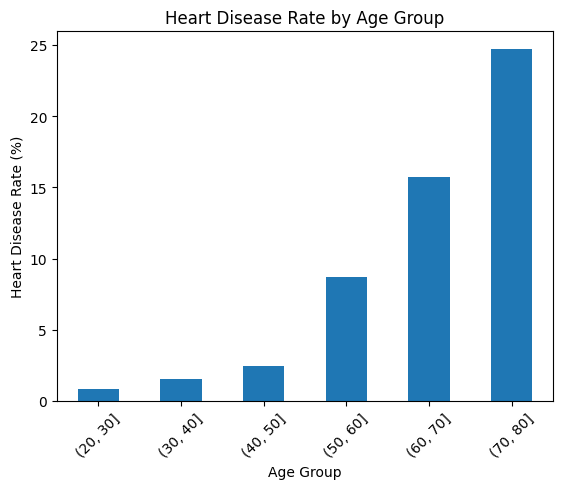

In [25]:
age_risk.plot(kind="bar")

plt.xlabel("Age Group")
plt.ylabel("Heart Disease Rate (%)")
plt.title("Heart Disease Rate by Age Group")
plt.xticks(rotation=45)
plt.show()

In [26]:
df.groupby("hypertension")["heart_disease"].mean() * 100

hypertension
0     3.653233
1    18.924021
Name: heart_disease, dtype: float64

In [27]:
hypertension_risk = df.groupby("hypertension")["heart_disease"].mean() * 100

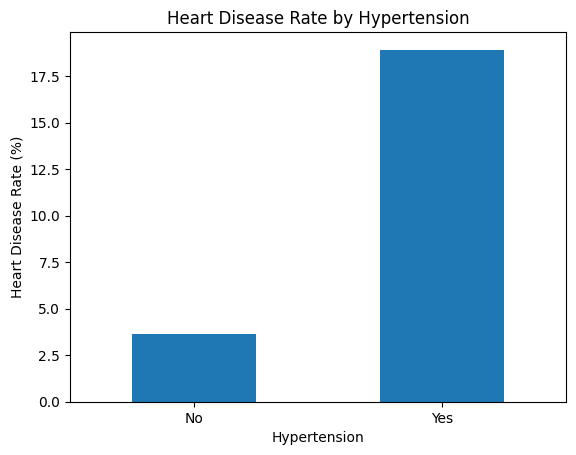

In [28]:
hypertension_risk.plot(kind="bar")

plt.xlabel("Hypertension")
plt.ylabel("Heart Disease Rate (%)")
plt.title("Heart Disease Rate by Hypertension")
plt.xticks([0, 1], ["No", "Yes"], rotation=0)
plt.show()

In [29]:
df.groupby("high_cholesterol")["heart_disease"].mean() * 100

high_cholesterol
0     5.580110
1    16.683778
Name: heart_disease, dtype: float64

In [30]:
df.groupby("diabetes")["heart_disease"].mean() * 100

diabetes
0     6.500426
1    25.342466
Name: heart_disease, dtype: float64

In [31]:
df.groupby("smoking_current")["heart_disease"].mean() * 100

smoking_current
0    9.511286
1    9.253731
Name: heart_disease, dtype: float64

In [32]:
df.groupby("family_history_heart_attack")["heart_disease"].mean() * 100

family_history_heart_attack
0     7.717637
1    21.438646
Name: heart_disease, dtype: float64

In [33]:
df.groupby("physically_active")["heart_disease"].mean() * 100

physically_active
0    12.827511
1     7.815846
Name: heart_disease, dtype: float64

In [34]:
df.groupby("sex")["heart_disease"].mean() * 100

sex
1.0    12.328767
2.0     6.766655
Name: heart_disease, dtype: float64

In [35]:
df.corr(numeric_only=True)["heart_disease"].sort_values(ascending=False)

heart_disease                  1.000000
age                            0.289729
taking_cholesterol_meds        0.285625
taking_bp_meds                 0.259428
hypertension                   0.253285
told_stroke                    0.236288
diabetes                       0.234366
taking_insulin                 0.197536
high_cholesterol               0.180905
taking_diabetes_pills          0.158583
family_history_heart_attack    0.156250
smoking_ever                   0.135646
told_prediabetes               0.020135
smoking_current               -0.003384
race_ethnicity                -0.022229
poverty_income_ratio          -0.053342
education                     -0.064337
physically_active             -0.080442
sex                           -0.094963
Name: heart_disease, dtype: float64

In [36]:
corr = df.corr(numeric_only=True)["heart_disease"].drop("heart_disease")
corr = corr.sort_values()

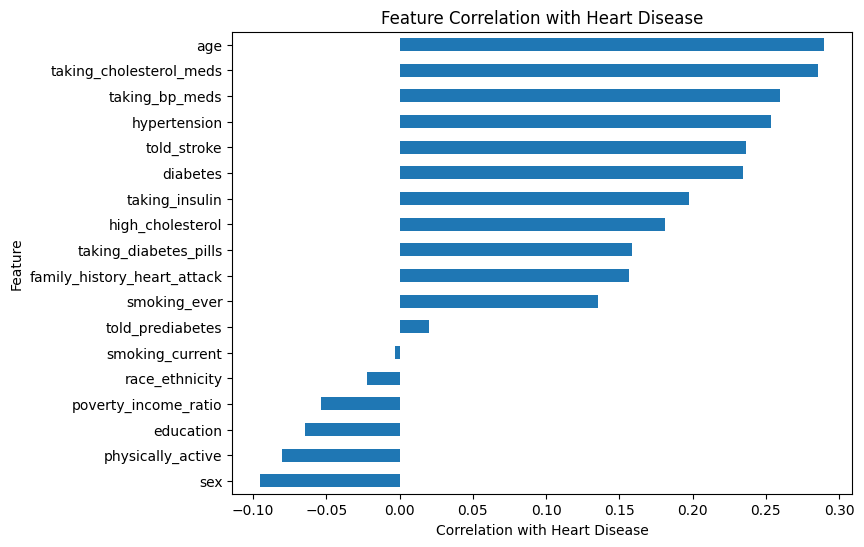

In [37]:
corr.plot(kind="barh", figsize=(8, 6))

plt.xlabel("Correlation with Heart Disease")
plt.ylabel("Feature")
plt.title("Feature Correlation with Heart Disease")
plt.show()

In [38]:
from sklearn.model_selection import train_test_split

In [39]:
X = df.drop("heart_disease", axis=1)

In [40]:
X.shape

(5568, 19)

In [41]:
X.shape

(5568, 19)

In [42]:
X.columns

Index(['taking_bp_meds', 'taking_cholesterol_meds', 'age', 'sex',
       'race_ethnicity', 'education', 'poverty_income_ratio', 'taking_insulin',
       'taking_diabetes_pills', 'told_prediabetes', 'told_stroke',
       'family_history_heart_attack', 'diabetes', 'smoking_ever',
       'smoking_current', 'physically_active', 'hypertension',
       'high_cholesterol', 'age_group'],
      dtype='object')

In [43]:
X = df.drop(["heart_disease", "age_group"], axis=1)

In [44]:
X.shape

(5568, 18)

In [45]:
y = df["heart_disease"]

In [46]:
y.shape

(5568,)

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [48]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(4454, 18)
(1114, 18)
(4454,)
(1114,)


In [49]:
y_train.value_counts()

heart_disease
0    4046
1     408
Name: count, dtype: int64

In [50]:
import pandas as pd 

In [51]:
import imblearn
print(imblearn.__version__)

0.13.0


In [52]:
from imblearn.over_sampling import SMOTE

In [53]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [54]:
y_train_smote.value_counts()

heart_disease
0    4046
1    4046
Name: count, dtype: int64

In [55]:
from sklearn.linear_model import LogisticRegression

In [56]:
model_lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [57]:
model_lr.fit(X_train_smote, y_train_smote)

LogisticRegression(max_iter=1000, random_state=42)

In [58]:
y_pred_lr = model_lr.predict(X_test)

In [59]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)
cm

array([[755, 240],
       [ 31,  88]])

In [60]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

Accuracy : 0.7567324955116697
Precision: 0.2682926829268293
Recall   : 0.7394957983193278
F1 Score : 0.39373601789709173


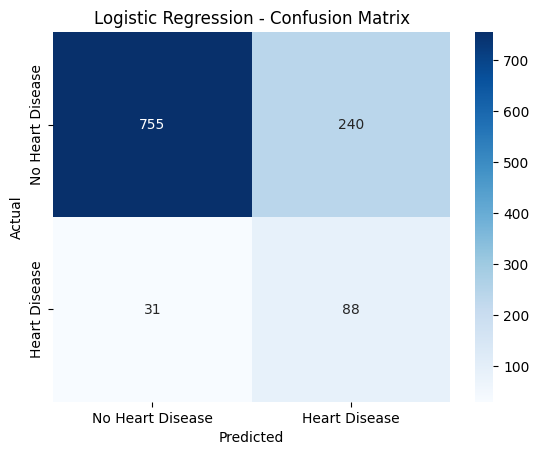

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Heart Disease", "Heart Disease"],
    yticklabels=["No Heart Disease", "Heart Disease"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [64]:
from sklearn.ensemble import RandomForestClassifier

In [65]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [66]:
rf_model.fit(X_train_smote, y_train_smote)

RandomForestClassifier(n_estimators=200, random_state=42)

In [67]:
y_pred_rf = rf_model.predict(X_test)

In [68]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Random Forest")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

Random Forest
Accuracy : 0.874326750448833
Precision: 0.3764705882352941
Recall   : 0.2689075630252101
F1 Score : 0.3137254901960784


In [69]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_rf

array([[942,  53],
       [ 87,  32]])

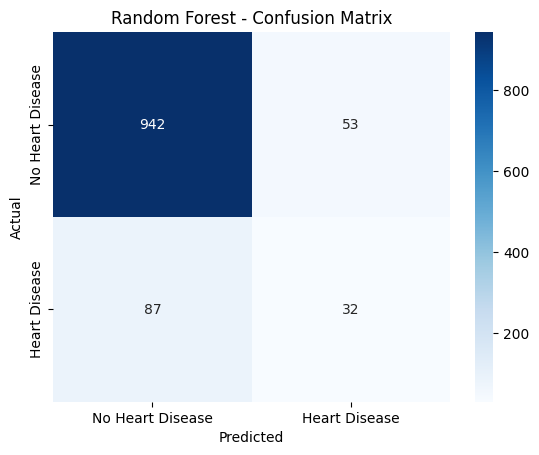

In [70]:
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Heart Disease", "Heart Disease"],
    yticklabels=["No Heart Disease", "Heart Disease"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [71]:
from sklearn.preprocessing import StandardScaler

In [72]:
scaler = StandardScaler()

In [73]:
X_train_scaled = scaler.fit_transform(X_train_smote)

In [74]:
X_test_scaled = scaler.transform(X_test)

In [75]:
print("Training shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Training shape: (8092, 18)
Test shape: (1114, 18)


In [76]:
from sklearn.svm import SVC

In [77]:
svm_model = SVC(
    kernel="rbf",
    random_state=42
)

In [78]:
svm_model.fit(X_train_scaled, y_train_smote)

SVC(random_state=42)

In [79]:
y_pred_svm = svm_model.predict(X_test_scaled)

In [80]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("SVM")
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))

SVM
Accuracy : 0.7782764811490126
Precision: 0.244
Recall   : 0.5126050420168067
F1 Score : 0.33062330623306235


In [81]:
from sklearn.metrics import confusion_matrix

cm_svm = confusion_matrix(y_test, y_pred_svm)
cm_svm

array([[806, 189],
       [ 58,  61]])

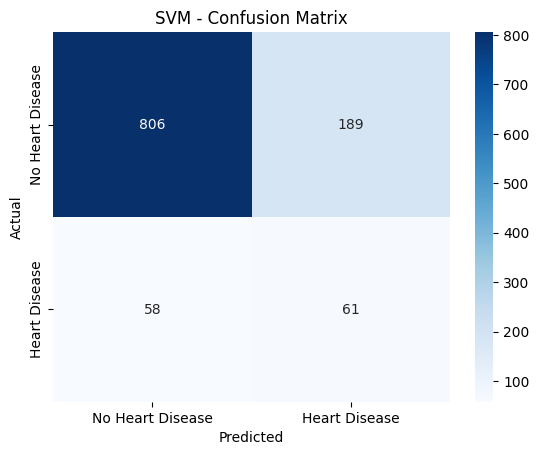

In [82]:
sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Heart Disease", "Heart Disease"],
    yticklabels=["No Heart Disease", "Heart Disease"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM - Confusion Matrix")
plt.show()

In [85]:
from xgboost import XGBClassifier

In [86]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_smote, y_train_smote)

y_pred_xgb = xgb_model.predict(X_test)

In [87]:
print("XGBoost")
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))

XGBoost
Accuracy : 0.8608617594254937
Precision: 0.34210526315789475
Recall   : 0.3277310924369748
F1 Score : 0.33476394849785407


In [88]:
results = {
    "Logistic Regression": [
        accuracy_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr)
    ],
    
    "Random Forest": [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf)
    ],
    
    "SVM": [
        accuracy_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_svm)
    ],
    
    "XGBoost": [
        accuracy_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_xgb)
    ]
}

In [89]:
comparison_df = pd.DataFrame(
    results,
    index=["Accuracy", "Precision", "Recall", "F1 Score"]
).T

comparison_df

,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.756732,0.268293,0.739496,0.393736
Random Forest,0.874327,0.376471,0.268908,0.313725
SVM,0.778276,0.244000,0.512605,0.330623
XGBoost,0.860862,0.342105,0.327731,0.334764


In [90]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model_lr.coef_[0]
})

feature_importance

,Feature,Coefficient
0,taking_bp_meds,-0.500551
1,taking_cholesterol_meds,0.885279
2,age,0.056175
3,sex,-0.780283
4,race_ethnicity,-0.045664
5,education,0.056952
6,poverty_income_ratio,-0.176910
7,taking_insulin,-0.079377
8,taking_diabetes_pills,-0.899433
9,told_prediabetes,-0.876628


In [91]:
feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

feature_importance

,Feature,Coefficient,Absolute_Coefficient
14,smoking_current,-1.155204,1.155204
16,hypertension,1.109836,1.109836
15,physically_active,-1.012177,1.012177
8,taking_diabetes_pills,-0.899433,0.899433
1,taking_cholesterol_meds,0.885279,0.885279
9,told_prediabetes,-0.876628,0.876628
3,sex,-0.780283,0.780283
17,high_cholesterol,-0.592625,0.592625
0,taking_bp_meds,-0.500551,0.500551
13,smoking_ever,0.436882,0.436882


In [92]:
lr_scaled = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_scaled.fit(X_train_scaled, y_train_smote)

LogisticRegression(max_iter=1000, random_state=42)

In [93]:
y_pred_lr_scaled = lr_scaled.predict(X_test_scaled)

In [94]:
print("Scaled Logistic Regression")
print("Accuracy :", accuracy_score(y_test, y_pred_lr_scaled))
print("Precision:", precision_score(y_test, y_pred_lr_scaled))
print("Recall   :", recall_score(y_test, y_pred_lr_scaled))
print("F1 Score :", f1_score(y_test, y_pred_lr_scaled))

Scaled Logistic Regression
Accuracy : 0.7567324955116697
Precision: 0.2682926829268293
Recall   : 0.7394957983193278
F1 Score : 0.39373601789709173


In [95]:
feature_importance_scaled = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr_scaled.coef_[0]
})

feature_importance_scaled["Absolute_Coefficient"] = (
    feature_importance_scaled["Coefficient"].abs()
)

feature_importance_scaled = feature_importance_scaled.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

feature_importance_scaled

,Feature,Coefficient,Absolute_Coefficient
2,age,0.970947,0.970947
16,hypertension,0.559581,0.559581
15,physically_active,-0.507183,0.507183
1,taking_cholesterol_meds,0.413771,0.413771
14,smoking_current,-0.386486,0.386486
3,sex,-0.367386,0.367386
8,taking_diabetes_pills,-0.309117,0.309117
17,high_cholesterol,-0.292905,0.292905
6,poverty_income_ratio,-0.248686,0.248686
0,taking_bp_meds,-0.247802,0.247802


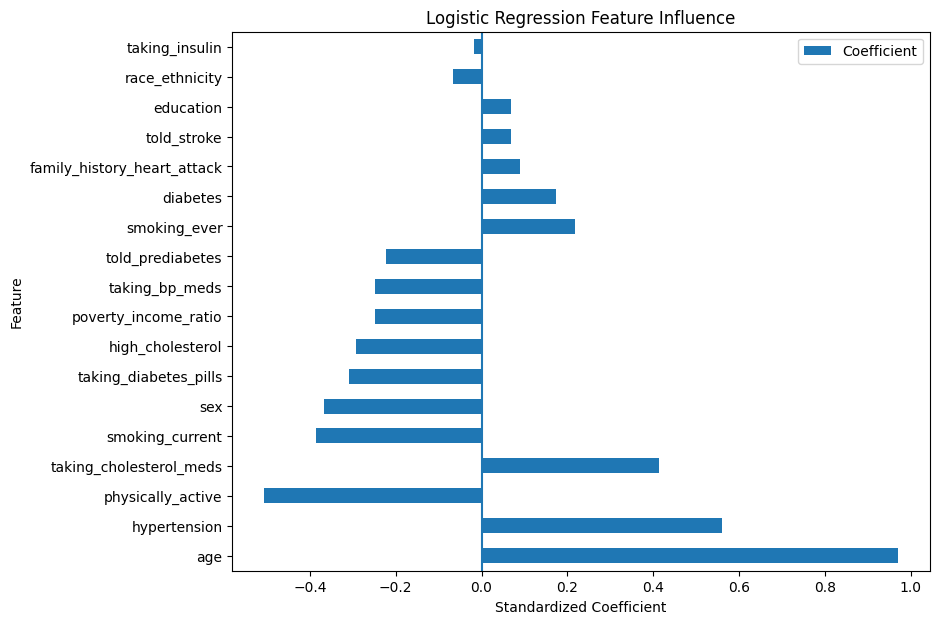

In [96]:
feature_importance_scaled.plot(
    x="Feature",
    y="Coefficient",
    kind="barh",
    figsize=(9, 7)
)

plt.xlabel("Standardized Coefficient")
plt.ylabel("Feature")
plt.title("Logistic Regression Feature Influence")
plt.axvline(0)
plt.show()

In [97]:
import shap

In [98]:
explainer = shap.LinearExplainer(
    lr_scaled,
    X_train_scaled
)

Background dataset has 8092 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=8092 when initializing the masker.


In [99]:
shap_values = explainer(X_test_scaled)

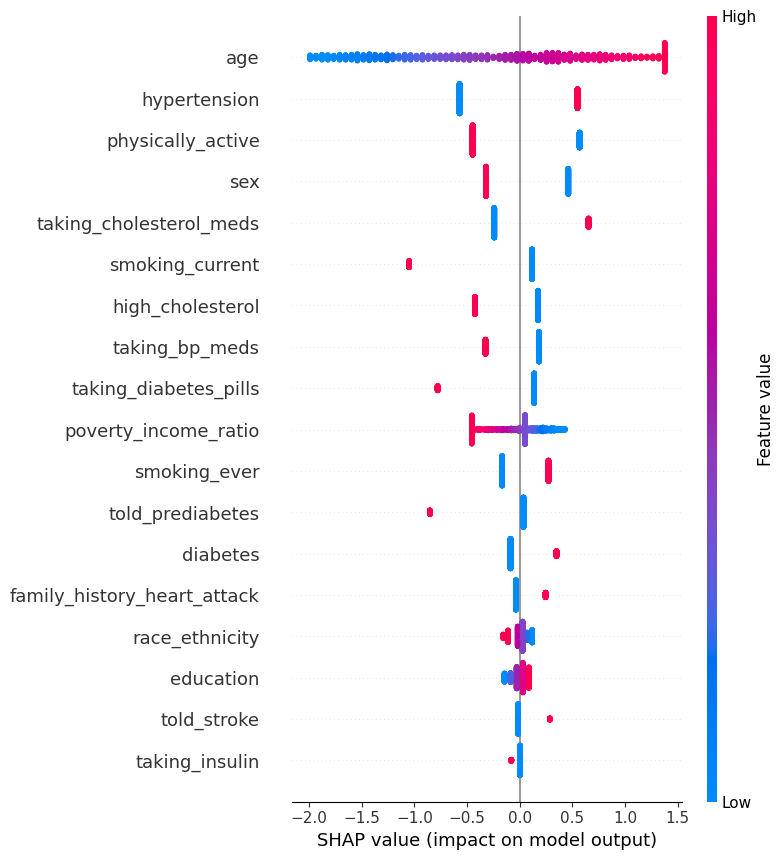

In [100]:
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X_train.columns
)

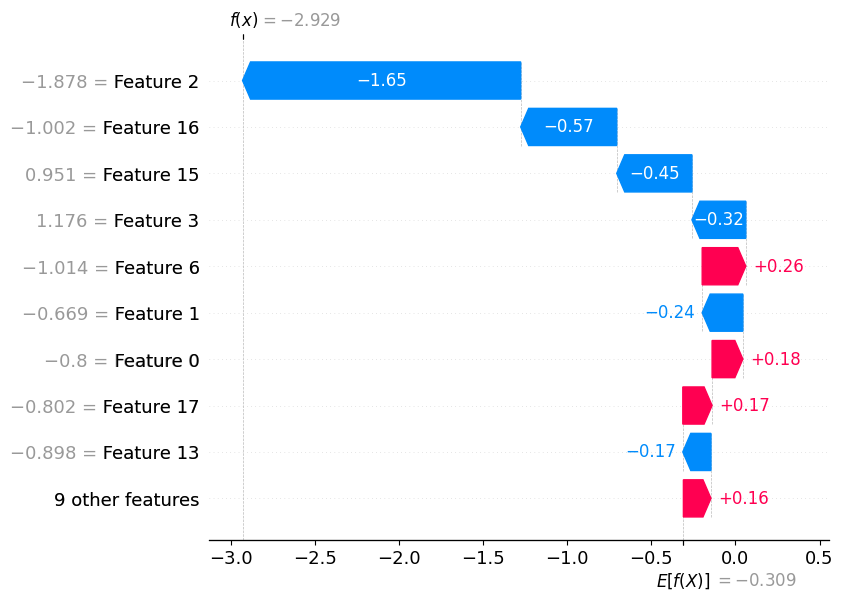

In [101]:
shap.plots.waterfall(shap_values[0])

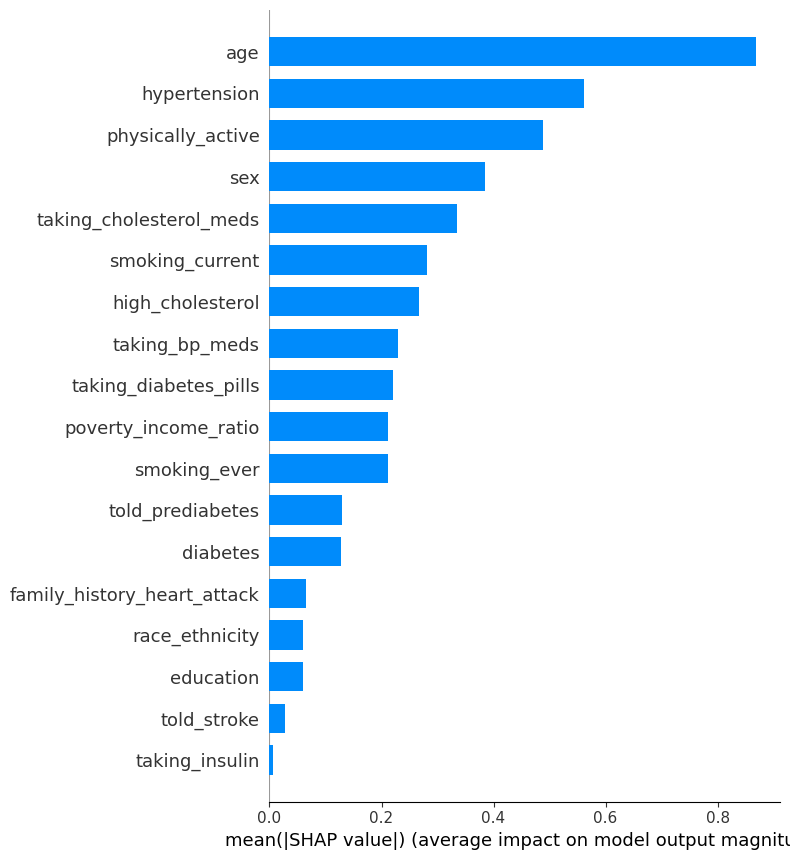

In [102]:
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X_train.columns,
    plot_type="bar"
)

In [103]:
y_prob_lr = lr_scaled.predict_proba(X_test_scaled)[:, 1]

In [104]:
from sklearn.metrics import roc_auc_score, average_precision_score

roc_auc = roc_auc_score(y_test, y_prob_lr)
pr_auc = average_precision_score(y_test, y_prob_lr)

print("ROC-AUC:", roc_auc)
print("PR-AUC :", pr_auc)

ROC-AUC: 0.8248638148726828
PR-AUC : 0.32812451787444136


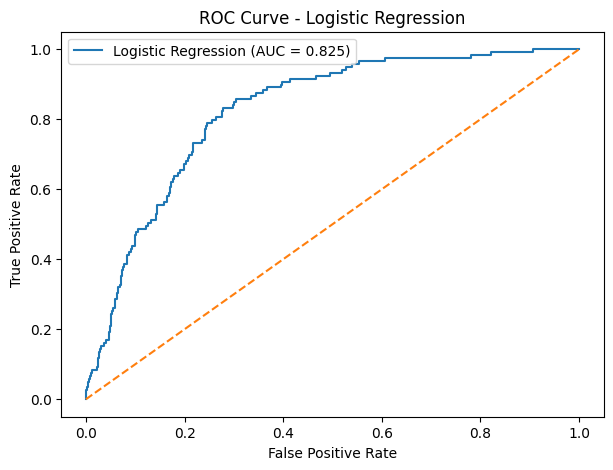

In [105]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

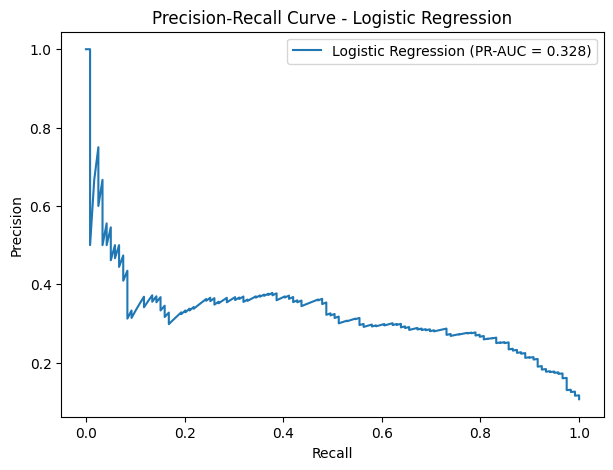

In [106]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds_pr = precision_recall_curve(
    y_test,
    y_prob_lr
)

plt.figure(figsize=(7, 5))

plt.plot(
    recall,
    precision,
    label=f"Logistic Regression (PR-AUC = {pr_auc:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Logistic Regression")
plt.legend()
plt.show()

In [107]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid_lr.fit(X_train_scaled, y_train_smote)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000, random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'solver': ['liblinear', 'lbfgs']},
             scoring='f1')

In [108]:
print("Best Parameters:", grid_lr.best_params_)
print("Best CV F1:", grid_lr.best_score_)

Best Parameters: {'C': 0.1, 'solver': 'lbfgs'}
Best CV F1: 0.766641326662693


In [109]:
best_lr = grid_lr.best_estimator_

y_pred_tuned = best_lr.predict(X_test_scaled)

In [110]:
print("Tuned Logistic Regression")
print("Accuracy :", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall   :", recall_score(y_test, y_pred_tuned))
print("F1 Score :", f1_score(y_test, y_pred_tuned))

Tuned Logistic Regression
Accuracy : 0.7594254937163375
Precision: 0.27217125382262997
Recall   : 0.7478991596638656
F1 Score : 0.3991031390134529


In [111]:
y_prob_tuned = best_lr.predict_proba(X_test_scaled)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob_tuned))
print("PR-AUC :", average_precision_score(y_test, y_prob_tuned))

ROC-AUC: 0.8250158354799206
PR-AUC : 0.3272754074887203


In [112]:
print("Tuned Logistic Regression")
print("Accuracy :", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall   :", recall_score(y_test, y_pred_tuned))
print("F1 Score :", f1_score(y_test, y_pred_tuned))

Tuned Logistic Regression
Accuracy : 0.7594254937163375
Precision: 0.27217125382262997
Recall   : 0.7478991596638656
F1 Score : 0.3991031390134529


In [113]:
final_results = {
    "Logistic Regression": [
        accuracy_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr),
        roc_auc_score(y_test, y_prob_lr),
        average_precision_score(y_test, y_prob_lr)
    ],

    "Random Forest": [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf),
        roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1]),
        average_precision_score(y_test, rf_model.predict_proba(X_test)[:, 1])
    ],

    "SVM": [
        accuracy_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_svm),
        roc_auc_score(y_test, svm_model.decision_function(X_test_scaled)),
        average_precision_score(y_test, svm_model.decision_function(X_test_scaled))
    ],

    "XGBoost": [
        accuracy_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_xgb),
        roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1]),
        average_precision_score(y_test, xgb_model.predict_proba(X_test)[:, 1])
    ],

    "Tuned Logistic Regression": [
        accuracy_score(y_test, y_pred_tuned),
        precision_score(y_test, y_pred_tuned),
        recall_score(y_test, y_pred_tuned),
        f1_score(y_test, y_pred_tuned),
        roc_auc_score(y_test, y_prob_tuned),
        average_precision_score(y_test, y_prob_tuned)
    ]
}

In [114]:
final_comparison = pd.DataFrame(
    final_results,
    index=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC"
    ]
).T

final_comparison.sort_values(
    "F1 Score",
    ascending=False
)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
Tuned Logistic Regression,0.759425,0.272171,0.747899,0.399103,0.825016,0.327275
Logistic Regression,0.756732,0.268293,0.739496,0.393736,0.824864,0.328125
XGBoost,0.860862,0.342105,0.327731,0.334764,0.838132,0.335578
SVM,0.778276,0.244000,0.512605,0.330623,0.761471,0.271888
Random Forest,0.874327,0.376471,0.268908,0.313725,0.839973,0.314200


In [115]:
from sklearn.metrics import precision_score, recall_score, f1_score

threshold = 0.5

y_pred_threshold = (y_prob_tuned >= threshold).astype(int)

print("Threshold:", threshold)
print("Precision:", precision_score(y_test, y_pred_threshold))
print("Recall   :", recall_score(y_test, y_pred_threshold))
print("F1 Score :", f1_score(y_test, y_pred_threshold))

Threshold: 0.5
Precision: 0.27217125382262997
Recall   : 0.7478991596638656
F1 Score : 0.3991031390134529


In [116]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

for threshold in thresholds:
    y_pred = (y_prob_tuned >= threshold).astype(int)

    print(
        f"Threshold: {threshold:.1f} | "
        f"Precision: {precision_score(y_test, y_pred):.3f} | "
        f"Recall: {recall_score(y_test, y_pred):.3f} | "
        f"F1: {f1_score(y_test, y_pred):.3f}"
    )
    

Threshold: 0.1 | Precision: 0.138 | Recall: 0.975 | F1: 0.242
Threshold: 0.2 | Precision: 0.176 | Recall: 0.950 | F1: 0.297
Threshold: 0.3 | Precision: 0.207 | Recall: 0.916 | F1: 0.338
Threshold: 0.4 | Precision: 0.239 | Recall: 0.857 | F1: 0.374
Threshold: 0.5 | Precision: 0.272 | Recall: 0.748 | F1: 0.399


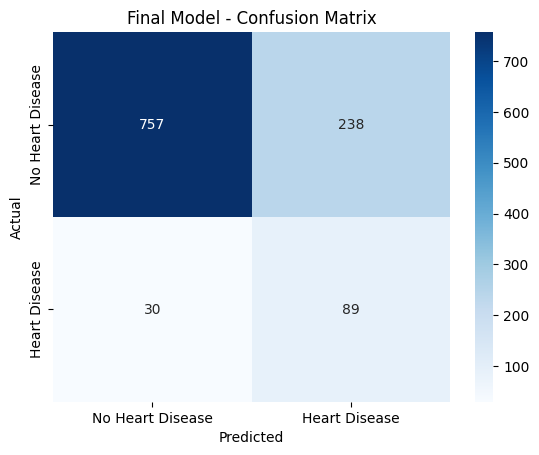

In [117]:
from sklearn.metrics import confusion_matrix

cm_final = confusion_matrix(y_test, y_pred_tuned)

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Heart Disease", "Heart Disease"],
    yticklabels=["No Heart Disease", "Heart Disease"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final Model - Confusion Matrix")
plt.show()

In [118]:
import joblib

joblib.dump(best_lr, "heart_disease_model.pkl")

['heart_disease_model.pkl']

In [119]:
joblib.dump(scaler, "heart_disease_scaler.pkl")

['heart_disease_scaler.pkl']

In [120]:
import joblib

loaded_model = joblib.load("heart_disease_model.pkl")
loaded_scaler = joblib.load("heart_disease_scaler.pkl")

In [121]:
print(type(loaded_model))
print(type(loaded_scaler))

<class 'sklearn.linear_model._logistic.LogisticRegression'>
<class 'sklearn.preprocessing._data.StandardScaler'>


In [122]:
sample_patient = X_test.iloc[[0]]

sample_patient

,taking_bp_meds,taking_cholesterol_meds,age,sex,race_ethnicity,education,poverty_income_ratio,taking_insulin,taking_diabetes_pills,told_prediabetes,told_stroke,family_history_heart_attack,diabetes,smoking_ever,smoking_current,physically_active,hypertension,high_cholesterol
1168,0,0,26.0,2.0,4.0,4.0,0.96,0,0,0,0,0,0,0,0,1,0,0


In [123]:
sample_scaled = loaded_scaler.transform(sample_patient)

prediction = loaded_model.predict(sample_scaled)[0]
probability = loaded_model.predict_proba(sample_scaled)[0][1]

print("Prediction:", prediction)
print("Heart Disease Probability:", round(probability * 100, 2), "%")

Prediction: 0
Heart Disease Probability: 5.21 %


In [124]:
def predict_heart_disease(patient_data):
    patient_scaled = loaded_scaler.transform(patient_data)

    prediction = loaded_model.predict(patient_scaled)[0]
    probability = loaded_model.predict_proba(patient_scaled)[0][1]

    if prediction == 1:
        result = "Heart Disease Risk"
    else:
        result = "No Heart Disease Risk"

    return result, probability

In [125]:
result, probability = predict_heart_disease(sample_patient)

print("Result:", result)
print("Probability:", round(probability * 100, 2), "%")

Result: No Heart Disease Risk
Probability: 5.21 %
